# Statlog German Credit Card Dataset - Complete EDA & R3 Diagnostic
### Risk-Aware Dynamic Model Router (R3) - Financial Risk Suite

This notebook performs EDA on the Statlog German Credit dataset ($N = 1,000$, $d = 20$).
It covers:
1. **Credit Risk Data Profiling** (Good vs Bad Credit Risk)
2. **Financial Feature Distributions** (`duration`, `credit_amount`, `age`)
3. **Categorical Risk Drivers** (`checking_status`, `credit_history`, `savings_status`)
4. **R3 Diagnostic Operating Window Computation** ($\Delta_{\text{Oracle}}$ & $\bar{\rho}_e$)

In [2]:
# --- 1. Load Libraries & Dataset ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print('Fetching German Credit dataset from OpenML...')
credit = fetch_openml(data_id=31, as_frame=True, parser='auto')
df = credit.frame.copy()

print(f'Dataset Shape: {df.shape}')
df.head()

Fetching German Credit dataset from OpenML...
Dataset Shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


--- Target Class Distribution ---
       Count  Percentage (%)
class                       
good     700            70.0
bad      300            30.0


/tmp/ipykernel_5350/2680966377.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[0], palette='Set2')


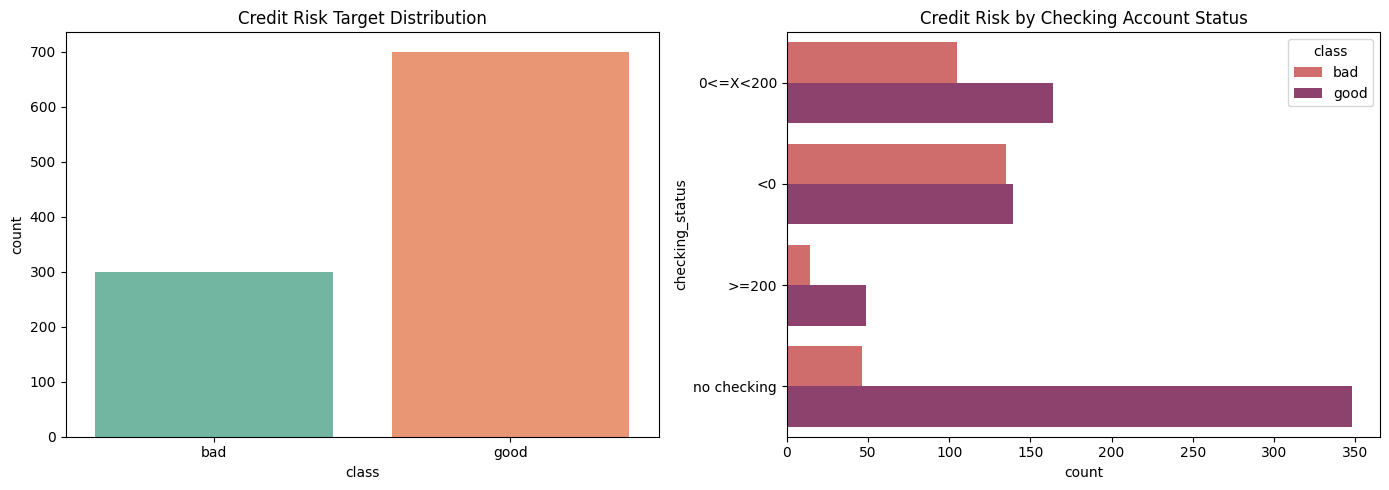

In [3]:
# --- 2. Target Class & Credit Risk Distribution ---
target_col = 'class' if 'class' in df.columns else 'foreign_worker' # OpenML target identification
if target_col not in df.columns:
    target_col = df.columns[-1]

print('--- Target Class Distribution ---')
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=target_col, ax=axes[0], palette='Set2')
axes[0].set_title('Credit Risk Target Distribution')

# Checking Status vs Target
if 'checking_status' in df.columns:
    sns.countplot(data=df, y='checking_status', hue=target_col, ax=axes[1], palette='flare')
    axes[1].set_title('Credit Risk by Checking Account Status')

plt.tight_layout()
plt.show()

--- Financial Features Descriptive Stats ---
                         count      mean          std    min     25%     50%  \
duration                1000.0    20.903    12.058814    4.0    12.0    18.0   
credit_amount           1000.0  3271.258  2822.736876  250.0  1365.5  2319.5   
installment_commitment  1000.0     2.973     1.118715    1.0     2.0     3.0   
residence_since         1000.0     2.845     1.103718    1.0     2.0     3.0   
age                     1000.0    35.546    11.375469   19.0    27.0    33.0   
existing_credits        1000.0     1.407     0.577654    1.0     1.0     1.0   
num_dependents          1000.0     1.155     0.362086    1.0     1.0     1.0   

                            75%      max  
duration                  24.00     72.0  
credit_amount           3972.25  18424.0  
installment_commitment     4.00      4.0  
residence_since            4.00      4.0  
age                       42.00     75.0  
existing_credits           2.00      4.0  
num_dependent

/tmp/ipykernel_5350/414570050.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='duration', ax=axes[1], palette='vlag')


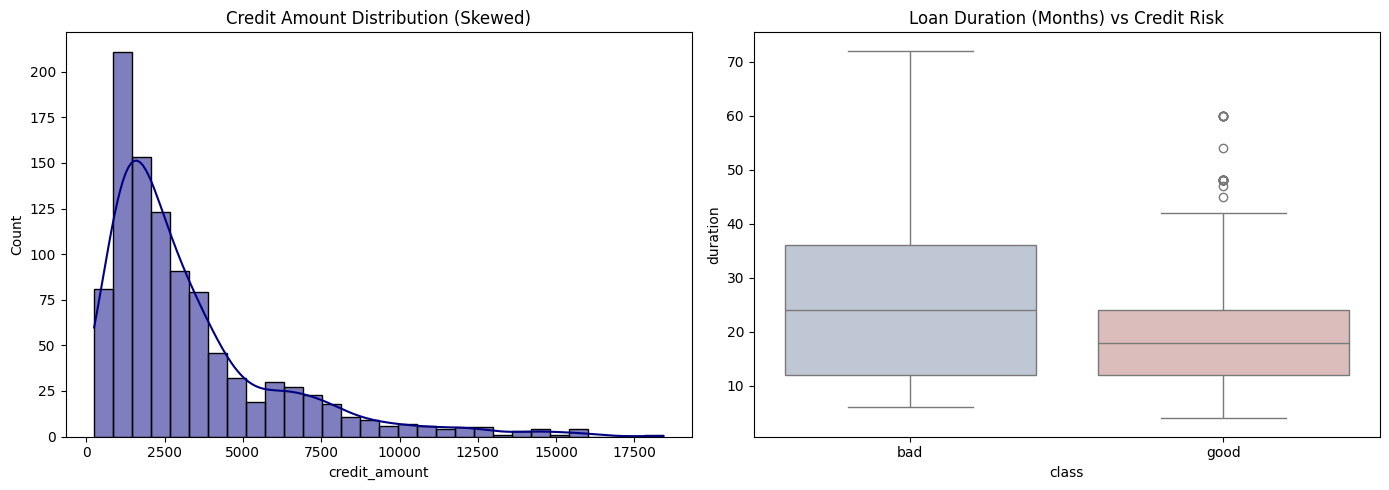

In [4]:
# --- 3. Continuous Financial Variables Analysis ---
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('--- Financial Features Descriptive Stats ---')
print(df[num_cols].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit Amount Distribution
if 'credit_amount' in df.columns:
    sns.histplot(df['credit_amount'], bins=30, ax=axes[0], color='navy', kde=True)
    axes[0].set_title('Credit Amount Distribution (Skewed)')

# Duration vs Target Risk
if 'duration' in df.columns:
    sns.boxplot(data=df, x=target_col, y='duration', ax=axes[1], palette='vlag')
    axes[1].set_title('Loan Duration (Months) vs Credit Risk')

plt.tight_layout()
plt.show()

In [5]:
# --- 4. R3 Diagnostic Operating Window Computation ---
X = df.drop(columns=[target_col])
y = (df[target_col].astype(str).str.contains('2|bad|1', case=False)).astype(int).values

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object', 'category']).columns

num_tf = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_tf = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_tf, num_features), ('cat', cat_tf, cat_features)])

X_proc = preprocessor.fit_transform(X)

# 5-Fold Stratified Split for OOF Signals
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LR': LogisticRegression(max_iter=1000),
    'XGB': HistGradientBoostingClassifier(),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300, random_state=42)
}

oof_probs = {m: np.zeros((len(y), 2)) for m in models}

for train_idx, val_idx in skf.split(X_proc, y):
    X_tr, X_val = X_proc[train_idx], X_proc[val_idx]
    y_tr = y[train_idx]
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        oof_probs[name][val_idx] = model.predict_proba(X_val)

# Compute Failure Vectors and R3 Diagnostics
accs, failures = {}, {}
for name in models:
    preds = np.argmax(oof_probs[name], axis=1)
    accs[name] = accuracy_score(y, preds)
    failures[name] = (preds != y).astype(int)

oracle_correct = np.any([failures[m] == 0 for m in models], axis=0)
acc_oracle = np.mean(oracle_correct)
best_static_acc = max(accs.values())
delta_oracle = acc_oracle - best_static_acc

rho_list = []
keys = list(models.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        r_i, r_j = failures[keys[i]], failures[keys[j]]
        rho_list.append(np.corrcoef(r_i, r_j)[0, 1])
avg_rho = np.mean(rho_list)

print('==================================================')
print('   GERMAN CREDIT DATASET - R3 DIAGNOSTIC EVAL     ')
print('==================================================')
for m in models:
    print(f'Base Model Accuracy [{m}]: {accs[m]*100:.2f}%')
print(f'Best Static Model Acc     : {best_static_acc*100:.2f}%')
print(f'Oracle Upper Bound Acc    : {acc_oracle*100:.2f}%')
print(f'Oracle Headroom (Delta)   : {delta_oracle*100:.2f}%')
print(f'Pairwise Error Corr (rho) : {avg_rho:.3f}')
print('--------------------------------------------------')
if delta_oracle >= 0.03 and avg_rho <= 0.45:
    print('STATUS: PASS -> Credit Card dataset is OPTIMAL for R3 Dynamic Routing')
else:
    print(' Static ensemble recommended')
print('==================================================')

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


   GERMAN CREDIT DATASET - R3 DIAGNOSTIC EVAL     
Base Model Accuracy [LR]: 74.60%
Base Model Accuracy [XGB]: 74.20%
Base Model Accuracy [MLP]: 71.90%
Best Static Model Acc     : 74.60%
Oracle Upper Bound Acc    : 85.60%
Oracle Headroom (Delta)   : 11.00%
Pairwise Error Corr (rho) : 0.568
--------------------------------------------------
 Static ensemble recommended


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
